In [ ]:
%load_ext autoreload
%autoreload 2

# Eva Data

This notebook builds a `MultiDataset` containing exactly one `ZarrDataset`, loads one batch, visualizes one image with `mediapy`, and prints the rest of the batch.

In [1]:
from pathlib import Path

import cv2
import imageio_ffmpeg
import mediapy as mpy
import numpy as np
import torch

from egomimic.rldb.embodiment.eva import Eva
from egomimic.rldb.embodiment.human import Aria
from egomimic.rldb.zarr.zarr_dataset_multi import MultiDataset, ZarrDataset
from egomimic.rldb.zarr.zarr_dataset_multi import S3EpisodeResolver
from egomimic.rldb.filters import DatasetFilter
from egomimic.utils.egomimicUtils import (
    INTRINSICS,
    cam_frame_to_cam_pixels,
    nds,
)
from egomimic.utils.aws.aws_data_utils import load_env

# Ensure mediapy can find an ffmpeg executable in this environment
mpy.set_ffmpeg(imageio_ffmpeg.get_ffmpeg_exe())

/root/miniconda3/envs/emimic/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
TEMP_DIR = "/coc/flash7/scratch/egoverseS3ZarrDataset/" # replace with your own temp directory for caching S3 data
load_env()

In [5]:
# key_map = Eva.get_keymap()
# transform_list = Eva.get_transform_list()
key_map = Eva.get_keymap(keymap_mode="cartesian")
transform_list = Eva.get_transform_list(mode="cartesian_wristframe_ypr")

resolver = S3EpisodeResolver(
    TEMP_DIR, key_map=key_map, transform_list=transform_list
)
filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2026-01-03-02-16-02-519000'}"
    ]
)
multi_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(multi_ds, batch_size=1, shuffle=False)

Tables in schema 'app': ['episodes']
cp s3://rldb/processed_v3/eva/2026-01-03-02-16-02-519000.zarr/images.right_wrist/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2026-01-03-02-16-02-519000/images.right_wrist/zarr.json
cp s3://rldb/processed_v3/eva/2026-01-03-02-16-02-519000.zarr/annotations/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2026-01-03-02-16-02-519000/annotations/zarr.json
cp s3://rldb/processed_v3/eva/2026-01-03-02-16-02-519000.zarr/images.front_1/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2026-01-03-02-16-02-519000/images.front_1/zarr.json
cp s3://rldb/processed_v3/eva/2026-01-03-02-16-02-519000.zarr/left.cmd_gripper/c/0/0 /coc/flash7/scratch/egoverseS3ZarrDataset/2026-01-03-02-16-02-519000/left.cmd_gripper/c/0/0
cp s3://rldb/processed_v3/eva/2026-01-03-02-16-02-519000.zarr/left.cmd_ee_pose/c/0/0 /coc/flash7/scratch/egoverseS3ZarrDataset/2026-01-03-02-16-02-519000/left.cmd_ee_pose/c/0/0
cp s3://rldb/processed_v3/eva/2026-01-03-02-16-02-519000.zarr/le

/home/djy/EgoVerse/egomimic/utils/egomimicUtils.py:893: RuntimeWarning: divide by zero encountered in divide
  px_val = px_val / px_val[2, :]
/home/djy/EgoVerse/egomimic/utils/egomimicUtils.py:893: RuntimeWarning: invalid value encountered in divide
  px_val = px_val / px_val[2, :]


""

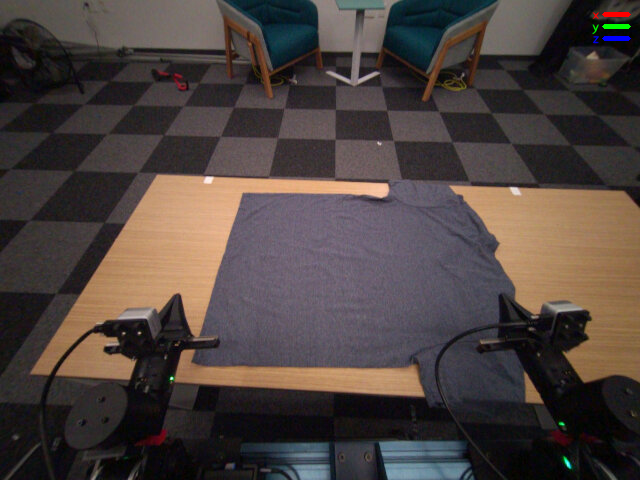

In [6]:
# Separate YPR visualization preview
for batch in loader:
    vis_ypr = Eva.viz_transformed_batch(batch, mode="axes")
    mpy.show_image(vis_ypr)
    break

In [7]:
images = []
for i, batch in enumerate(loader):
    vis = Eva.viz_transformed_batch(batch, mode="traj+rotation")
    images.append(vis)
    if i > 10:
        break

mpy.show_video(images, fps=30)

Got bad pixel_val:  [nan nan nan]
Got bad pixel_val:  [nan nan nan]
Got bad pixel_val:  [nan nan nan]
Got bad pixel_val:  [nan nan nan]


This browser does not support the video tag.


## Human Datasets
Mecka, Scale and Aria all use different key_maps 

In [11]:
intrinsics_key = "base"

key_map = Aria.get_keymap(keymap_mode="cartesian")
transform_list = Aria.get_transform_list(mode="cartesian")

resolver = S3EpisodeResolver(
    TEMP_DIR,
    key_map=key_map,
    transform_list=transform_list,
)

filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2025-10-29-22-06-00-425000'}"
        # "lambda row: row['episode_hash'] in {'692ee048ef7557106e6c4b8d'}" mecka
    ]
)


cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

Tables in schema 'app': ['episodes']
cp s3://rldb/processed_v3/aria/2025-10-29-22-06-00-425000.zarr/left.obs_ee_pose/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2025-10-29-22-06-00-425000/left.obs_ee_pose/zarr.json
cp s3://rldb/processed_v3/aria/2025-10-29-22-06-00-425000.zarr/annotations/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2025-10-29-22-06-00-425000/annotations/zarr.json
cp s3://rldb/processed_v3/aria/2025-10-29-22-06-00-425000.zarr/left.obs_wrist_pose/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2025-10-29-22-06-00-425000/left.obs_wrist_pose/zarr.json
cp s3://rldb/processed_v3/aria/2025-10-29-22-06-00-425000.zarr/images.front_1/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2025-10-29-22-06-00-425000/images.front_1/zarr.json
cp s3://rldb/processed_v3/aria/2025-10-29-22-06-00-425000.zarr/left.obs_keypoints/c/0/0 /coc/flash7/scratch/egoverseS3ZarrDataset/2025-10-29-22-06-00-425000/left.obs_keypoints/c/0/0
cp s3://rldb/processed_v3/aria/2025-10-29-22-

In [12]:
ims = []
for i, batch in enumerate(loader):
    vis = Aria.viz_transformed_batch(batch, mode="traj")
    ims.append(vis)
    # mpy.show_image(vis)

    # for k, v in batch.items():
    #     print(f"{k}: {tuple(v.shape)}")
    
    if i > 10:
        break

mpy.show_video(ims, fps=30)


This browser does not support the video tag.


In [13]:
# Aria YPR video (same data loop, YPR overlay)
ims_ypr = []
for i, batch in enumerate(loader):
    vis_ypr = Aria.viz_transformed_batch(batch, mode="axes")
    ims_ypr.append(vis_ypr)
    if i > 20:
        break

mpy.show_video(ims_ypr, fps=30)

This browser does not support the video tag.


In [15]:
key_map = Aria.get_keymap(keymap_mode="keypoints")
transform_list = Aria.get_transform_list(mode="keypoints_headframe_ypr")

resolver = S3EpisodeResolver(
    TEMP_DIR,
    key_map=key_map,
    transform_list=transform_list,
)

cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

Tables in schema 'app': ['episodes']


In [16]:
from egomimic.rldb.embodiment.human import _build_aria_keypoints_revert_eef_frame_transform_list
ims_keypoints = []
revert_transform_list = _build_aria_keypoints_revert_eef_frame_transform_list(is_quat=False)
for i, batch in enumerate(loader):
    vis_keypoints = Aria.viz_transformed_batch(batch, mode="keypoints", viz_batch_key="actions_keypoints")
    ims_keypoints.append(vis_keypoints)
    if i > 20:
        break

mpy.show_video(ims_keypoints, fps=30)

This browser does not support the video tag.


## Aria Gaze

In [17]:
from egomimic.utils.egomimicUtils import INTRINSICS, cam_frame_to_cam_pixels, draw_dot_on_frame, get_gaze_endpoint, ARIA_T_RGB_CPF
from egomimic.rldb.zarr.zarr_dataset_multi import MultiDataset, ZarrDataset
import mediapy as mpy
import numpy as np
import torch
from pathlib import Path

key_map_gaze = {
    "images.front_1": {"zarr_key": "images.front_1"},
    "eye_gaze": {"zarr_key": "obs_eye_gaze"},
}
intrinsics = INTRINSICS["base"]

filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2025-11-27-23-14-02-277000'}"
    ]
)

resolver = S3EpisodeResolver(
    TEMP_DIR, key_map=key_map_gaze
)
cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

Tables in schema 'app': ['episodes']
cp s3://rldb/processed_v3/aria/2025-11-27-23-14-02-277000.zarr/obs_eye_gaze/c/0/0 /coc/flash7/scratch/egoverseS3ZarrDataset/2025-11-27-23-14-02-277000/obs_eye_gaze/c/0/0
cp s3://rldb/processed_v3/aria/2025-11-27-23-14-02-277000.zarr/annotations/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2025-11-27-23-14-02-277000/annotations/zarr.json
cp s3://rldb/processed_v3/aria/2025-11-27-23-14-02-277000.zarr/images.front_1/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2025-11-27-23-14-02-277000/images.front_1/zarr.json
cp s3://rldb/processed_v3/aria/2025-11-27-23-14-02-277000.zarr/left.obs_ee_pose/zarr.json /coc/flash7/scratch/egoverseS3ZarrDataset/2025-11-27-23-14-02-277000/left.obs_ee_pose/zarr.json
cp s3://rldb/processed_v3/aria/2025-11-27-23-14-02-277000.zarr/left.obs_keypoints/c/0/0 /coc/flash7/scratch/egoverseS3ZarrDataset/2025-11-27-23-14-02-277000/left.obs_keypoints/c/0/0
cp s3://rldb/processed_v3/aria/2025-11-27-23-14-02-277000.zarr/left

In [18]:
ims_gaze = []
for i, batch in enumerate(loader):
    print(batch.keys())
    gaze_data = batch['eye_gaze'][0].numpy() # yaw (rads), pitch (rads), depth (m)
    if gaze_data[0] != -100: # value for no gaze estimate
        gaze_point_xyz = get_gaze_endpoint(gaze_data[0], gaze_data[1], gaze_data[2], ARIA_T_RGB_CPF)
        gaze_point_xyz = np.expand_dims(gaze_point_xyz, 0)
        gaze_point_pixel = cam_frame_to_cam_pixels(gaze_point_xyz, intrinsics)
        frame = batch['images.front_1'][0].permute(1,2,0).numpy() * 255
        vis = draw_dot_on_frame(frame, gaze_point_pixel, show=False)
        ims_gaze.append(vis)
        if i > 30:
            break

dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.robot_name', 'embodiment'])
dict_keys(['images.front_1', 'eye_gaze', 'metadata.r

In [19]:
mpy.show_video(ims_gaze, fps=30)

This browser does not support the video tag.


# Annotation Viz

In [22]:
from egomimic.rldb.embodiment.human import Scale
from egomimic.rldb.filters import DatasetFilter
intrinsics_key = "base"

key_map = Scale.get_keymap(keymap_mode="cartesian", annotation_key="annotations",)
transform_list = None

resolver = S3EpisodeResolver(
    folder_path = "/coc/flash7/scratch/egoverseDebugDatasets/egoverseS3DatasetTest/",
    key_map=key_map,
    transform_list=transform_list,
)

filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2026-03-16-01-22-26-448000'}"
    ]
)

cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

Tables in schema 'app': ['episodes']
cp s3://rldb/processed_v3/eva/2026-03-16-01-22-26-448000.zarr/annotations/zarr.json /coc/flash7/scratch/egoverseDebugDatasets/egoverseS3DatasetTest/2026-03-16-01-22-26-448000/annotations/zarr.json
cp s3://rldb/processed_v3/eva/2026-03-16-01-22-26-448000.zarr/left.cmd_gripper/c/0/0 /coc/flash7/scratch/egoverseDebugDatasets/egoverseS3DatasetTest/2026-03-16-01-22-26-448000/left.cmd_gripper/c/0/0
cp s3://rldb/processed_v3/eva/2026-03-16-01-22-26-448000.zarr/left.cmd_ee_pose/c/0/0 /coc/flash7/scratch/egoverseDebugDatasets/egoverseS3DatasetTest/2026-03-16-01-22-26-448000/left.cmd_ee_pose/c/0/0
cp s3://rldb/processed_v3/eva/2026-03-16-01-22-26-448000.zarr/left.cmd_ee_pose/zarr.json /coc/flash7/scratch/egoverseDebugDatasets/egoverseS3DatasetTest/2026-03-16-01-22-26-448000/left.cmd_ee_pose/zarr.json
cp s3://rldb/processed_v3/eva/2026-03-16-01-22-26-448000.zarr/images.right_wrist/zarr.json /coc/flash7/scratch/egoverseDebugDatasets/egoverseS3DatasetTest/2026-0

In [23]:
batch = next(iter(loader))
batch['annotations']

[]

In [24]:
ims_annotations = []
for i, batch in enumerate(loader):
    vis = Scale.viz_transformed_batch(batch, mode="annotations", viz_batch_key="annotations")
    ims_annotations.append(vis)
    if i > 10:
        break
mpy.show_video(ims_annotations, fps=30)

This browser does not support the video tag.
